In [3]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED= 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False

In [4]:
DATA_PATH = "/content/trainset_40k_onlySent.xlsx"

df= pd.read_excel(DATA_PATH)
df = df[["formalForm", "inFormalForm"]].dropna().reset_index(drop=True)
df["formalForm"] = df["formalForm"].astype(str).str.strip()
df["inFormalForm"] = df["inFormalForm"].astype(str).str.strip()
df = df[(df["formalForm"] != "") & (df["inFormalForm"] != "")].reset_index(drop=True)

print("Number of sentence pairs:", len(df))
df.head()

Number of sentence pairs: 40018


,formalForm,inFormalForm
0,خدا شاهد است که من برای این کار چه قدر تلاش کردم,خدا شاهده که من چقدر برای این کار تلاش کردم
1,اینترنت‌مان در یک هفته تمام شد.,اینترنت مون تو یه هفته تموم شد.
2,داداشم این را روی میزم دید و گفت باز بی‌اجازه ...,اینو دید داداشم رو میزم و گفت باز بی اجازه در ...
3,دم غروب با مامانم دختر همسایه را با یک تاکسی ل...,با یه تاکسی لکنته دختر همسایه رو دم غروب رسوند...
4,این درس از چیزی که به‌نظر می‌رسد سخت‌تر است.,این درس از چیزی که بنظر میرسه سخت تره.


In [5]:
sample_pairs= df.sample(10, random_state=SEED).reset_index(drop=True)
pd.set_option("display.max_colwidth", None)
sample_pairs

,formalForm,inFormalForm
0,همسر من نه اخلاق دارد، نه صله‌رحم دارد و نه احساس دارد و خیلی کم پیش می‌آید که در خانۀ من مهمان بیاید و من واقعاً دلم می‌گیرد.,همسر من نه اخلاق داره ن صله رحم داره ن احساس داره و توخونه من خیلی کم پیش میاد مهمون بیاد ومن واقعا دلم میگیره.
1,با صدای در، هر دوی ما متعجب به طرف در برگشتیم.,با صدای در هر دوتامون متعجب برگشتیم طرف در
2,وقتی سینا هم ببیند نرفته‌ام ول می‌کند و می‌رود.,سینا هم وقتی ببینه نرفتم ول میکنه و میره
3,یعنی حتماً باید به دوا و درمان متوسل بشوم؟,یعنی حتما باید متوسل به دوادرمون بشم؟
4,دلم می‌خواهد سرم را روی شانه‌ات بگذارم، روی سینه‌ات، روی زانویت، چه می‌دانم دیگر پیش تو باشم و زارزار مثل باران گریه کنم.,دلم میخواد سرمو بذارم روی شونت، روی سـینت، روی زانـوت چـه میـدونم پیشت باشم دیگه و زار زار گریه کنم مثل بارون
5,الان هم او را عمل کرده‌اند.,الانم عملش کردن.
6,تا حالا خانواده را پیچانده‌اید که به مسافرت بروید؟,تا حالا خونوادرو پیچوندین برین مسافرت؟
7,به‌امید اینکه آمده و او هم خواب است، لامپ اتاقم را روشن کردم.,به امید این که اومده و اونم خوابه لامپ اتاقمو روشن کردم
8,وقتی تو را می‌بیند به‌خاطر غلط روخوانی‌ات تو را مسخره می‌کند!,وقتی می بینتت به خاطر غلط روخونیت مسخرت میکنه!
9,تختم هم همیشه شلخته است.,تختمم همیشه شلختس


**Observed linguistic modifications:**

- word contractions / vowel dropping (e.g. verb endings shortened)
- change of pronunciation-based spelling for common words
- dropped or merged function words
- colloquial verb conjugations replacing formal ones
- different word order in some sentences

In [6]:
def word_count(text):
    return len(text.split())

def char_count(text):
    return len(text)

df["formal_word_count"]= df["formalForm"].apply(word_count)
df["informal_word_count"]= df["inFormalForm"].apply(word_count)
df["formal_char_count"]= df["formalForm"].apply(char_count)
df["informal_char_count"]= df["inFormalForm"].apply(char_count)

df[["formal_word_count", "informal_word_count", "formal_char_count", "informal_char_count"]].head()

,formal_word_count,informal_word_count,formal_char_count,informal_char_count
0,12,10,48,43
1,6,7,31,31
2,22,21,93,84
3,24,22,123,114
4,9,9,44,38


In [7]:
stats = df[["formal_word_count", "informal_word_count", "formal_char_count", "informal_char_count"]].describe().T

stats["median"]= [
    df["formal_word_count"].median(),
    df["informal_word_count"].median(),
    df["formal_char_count"].median(),
    df["informal_char_count"].median(),
]

stats[["mean", "median", "std", "min", "max"]]

,mean,median,std,min,max
formal_word_count,12.344095,11.0,6.498607,1.0,67.0
informal_word_count,11.388725,10.0,6.527757,1.0,64.0
formal_char_count,62.619871,56.0,31.985095,9.0,322.0
informal_char_count,55.084062,48.0,30.048929,5.0,320.0


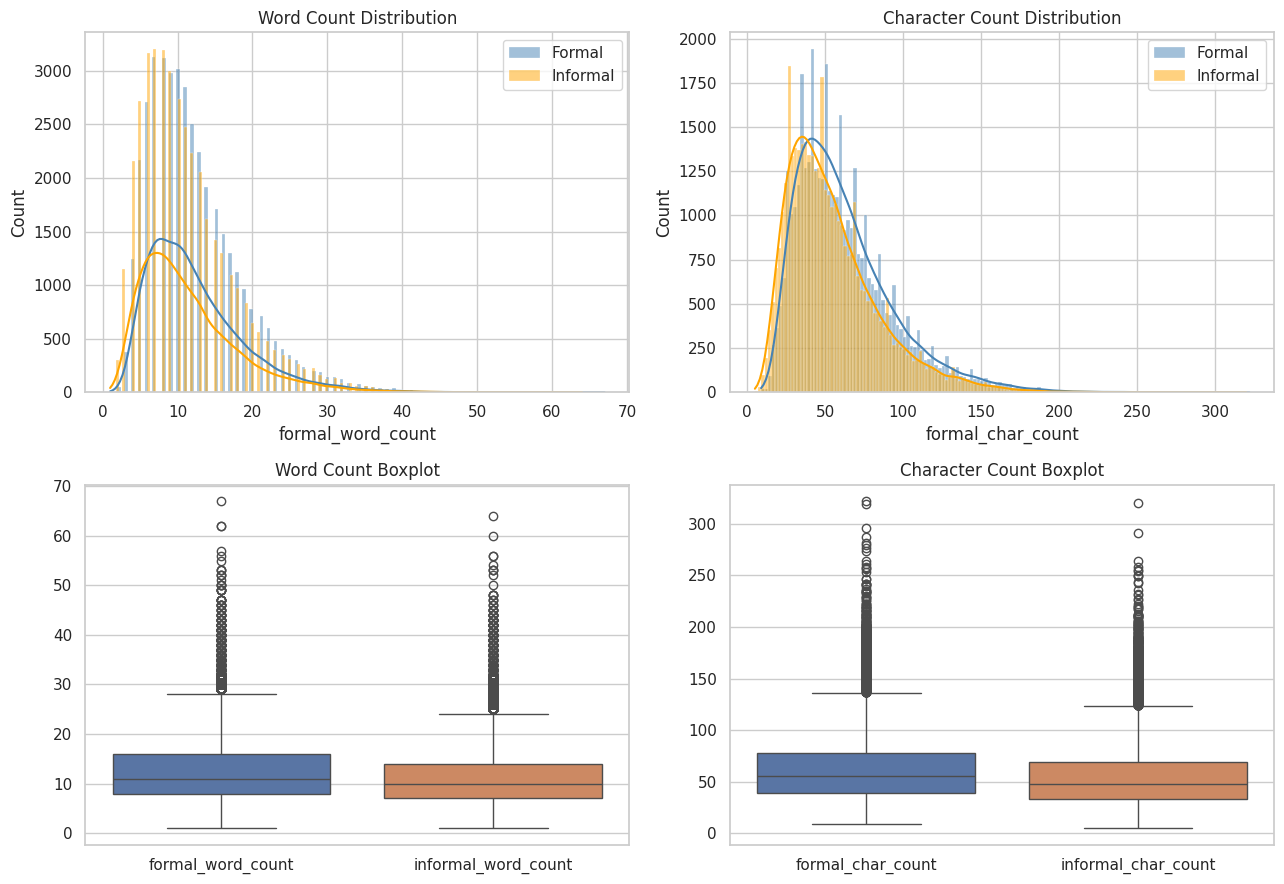

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df["formal_word_count"], color="steelblue", label="Formal",
             kde=True, ax=axes[0, 0], alpha=0.5)
sns.histplot(df["informal_word_count"], color="orange", label="Informal",
             kde=True, ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_title("Word Count Distribution")
axes[0, 0].legend()

sns.histplot(df["formal_char_count"], color="steelblue", label="Formal",
             kde=True, ax=axes[0, 1], alpha=0.5)
sns.histplot(df["informal_char_count"], color="orange", label="Informal",
             kde=True, ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title("Character Count Distribution")
axes[0, 1].legend()

sns.boxplot(data=df[["formal_word_count", "informal_word_count"]], ax=axes[1, 0])
axes[1, 0].set_title("Word Count Boxplot")

sns.boxplot(data=df[["formal_char_count", "informal_char_count"]], ax=axes[1, 1])
axes[1, 1].set_title("Character Count Boxplot")

plt.tight_layout()
plt.show()

Typically informal Persian sentences are shorter in both word and character
count than their formal counterparts, since informal speech drops function words and contracts verb endings.

In [9]:
def build_vocab(series):
    vocab= {}
    for sentence in series:
        for word in sentence.split():
            vocab[word] = vocab.get(word, 0) + 1
    return vocab

formal_vocab= build_vocab(df["formalForm"])
informal_vocab= build_vocab(df["inFormalForm"])

formal_words= set(formal_vocab.keys())
informal_words= set(informal_vocab.keys())

unique_to_formal= formal_words-informal_words
unique_to_informal= informal_words-formal_words
shared_words= formal_words & informal_words

print("Formal vocabulary size:", len(formal_words))
print("Informal vocabulary size:", len(informal_words))
print("Words unique to formal:", len(unique_to_formal))
print("Words unique to informal:", len(unique_to_informal))
print("Shared words:", len(shared_words))

Formal vocabulary size: 40360
Informal vocabulary size: 53852
Words unique to formal: 25005
Words unique to informal: 38497
Shared words: 15355


In [10]:
top20_formal= sorted(formal_vocab.items(), key=lambda x: x[1], reverse=True)[:20]
top20_informal= sorted(informal_vocab.items(), key=lambda x: x[1], reverse=True)[:20]

top_words_df = pd.DataFrame({
    "formal_word": [w for w, c in top20_formal],
    "formal_count": [c for w, c in top20_formal],
    "informal_word": [w for w, c in top20_informal],
    "informal_count": [c for w, c in top20_informal],
})
top_words_df

,formal_word,formal_count,informal_word,informal_count
0,را,21146,و,14338
1,که,16420,که,12878
2,و,15522,به,8090
3,به,12614,از,7645
4,از,9268,رو,6542
5,من,8228,این,5300
6,هم,7580,تو,5267
7,در,6818,یه,5202
8,این,6092,با,4429
9,است.,5641,من,4413


Informal Persian usually shows a *larger* raw vocabulary than formal Persian,
because the same formal word can be spelled/contracted in several different informal
ways (spelling isn't standardized in casual writing), which inflates the number of
distinct surface forms. Formal Persian, by contrast, follows more standardized spelling
rules, so the same word is written the same way every time.

### 1.4 Transformer Tokenization Complexity (7 Points)

In [11]:
from transformers import AutoTokenizer

MODEL_NAME = "HooshvareLab/bert-fa-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def whitespace_tokenize(text):
    return text.split()

def transformer_tokenize(text):
    return tokenizer.tokenize(text)

example= df.iloc[0]
print("Formal sentence:", example["formalForm"])
print("Whitespace tokens:", whitespace_tokenize(example["formalForm"]))
print("ParsBERT tokens:", transformer_tokenize(example["formalForm"]))
print()
print("Informal sentence:", example["inFormalForm"])
print("Whitespace tokens:", whitespace_tokenize(example["inFormalForm"]))
print("ParsBERT tokens:", transformer_tokenize(example["inFormalForm"]))

config.json:   0%|          | 0.00/440 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

Formal sentence: خدا شاهد است که من برای این کار چه قدر تلاش کردم
Whitespace tokens: ['خدا', 'شاهد', 'است', 'که', 'من', 'برای', 'این', 'کار', 'چه', 'قدر', 'تلاش', 'کردم']
ParsBERT tokens: ['خدا', 'شاهد', 'است', 'که', 'من', 'برای', 'این', 'کار', 'چه', 'قدر', 'تلاش', 'کردم']

Informal sentence: خدا شاهده که من چقدر برای این کار تلاش کردم
Whitespace tokens: ['خدا', 'شاهده', 'که', 'من', 'چقدر', 'برای', 'این', 'کار', 'تلاش', 'کردم']
ParsBERT tokens: ['خدا', 'شاهده', 'که', 'من', 'چقدر', 'برای', 'این', 'کار', 'تلاش', 'کردم']


In [12]:
for i in range(5):
    row = df.iloc[i]
    print("Formal whitespace  :", whitespace_tokenize(row["formalForm"]))
    print("Formal subword     :", transformer_tokenize(row["formalForm"]))
    print("Informal whitespace:", whitespace_tokenize(row["inFormalForm"]))
    print("Informal subword   :", transformer_tokenize(row["inFormalForm"]))
    print()

Formal whitespace  : ['خدا', 'شاهد', 'است', 'که', 'من', 'برای', 'این', 'کار', 'چه', 'قدر', 'تلاش', 'کردم']
Formal subword     : ['خدا', 'شاهد', 'است', 'که', 'من', 'برای', 'این', 'کار', 'چه', 'قدر', 'تلاش', 'کردم']
Informal whitespace: ['خدا', 'شاهده', 'که', 'من', 'چقدر', 'برای', 'این', 'کار', 'تلاش', 'کردم']
Informal subword   : ['خدا', 'شاهده', 'که', 'من', 'چقدر', 'برای', 'این', 'کار', 'تلاش', 'کردم']

Formal whitespace  : ['اینترنت\u200cمان', 'در', 'یک', 'هفته', 'تمام', 'شد.']
Formal subword     : ['اینترنت', '##مان', 'در', 'یک', 'هفته', 'تمام', 'شد', '.']
Informal whitespace: ['اینترنت', 'مون', 'تو', 'یه', 'هفته', 'تموم', 'شد.']
Informal subword   : ['اینترنت', 'مون', 'تو', 'یه', 'هفته', 'تموم', 'شد', '.']

Formal whitespace  : ['داداشم', 'این', 'را', 'روی', 'میزم', 'دید', 'و', 'گفت', 'باز', 'بی\u200cاجازه', 'در', 'کمد', 'من', 'را', 'باز', 'کردی', 'و', 'دست', 'به', 'کتاب\u200cهای', 'من', 'زدی؟']
Formal subword     : ['داداش', '##م', 'این', 'را', 'روی', 'میزم', 'دید', 'و', 'گفت', 'با

Notice that many informal words get broken into more subword pieces than their
formal counterparts, because ParsBERT's vocabulary was built mostly from formal/written
Persian, so it has fewer whole-word entries for colloquial spellings and has to fall
back to smaller subword fragments (often marked with `##`).

In [13]:
def token_inflation_factor(text):
    n_transformer= len(transformer_tokenize(text))
    n_whitespace= len(whitespace_tokenize(text))
    if n_whitespace == 0:
        return np.nan
    return n_transformer/n_whitespace

df["formal_TIF"]= df["formalForm"].apply(token_inflation_factor)
df["informal_TIF"]= df["inFormalForm"].apply(token_inflation_factor)

print("Formal TIF -> mean: {:.3f}, median: {:.3f}".format(
    df["formal_TIF"].mean(), df["formal_TIF"].median()))
print("Informal TIF -> mean: {:.3f}, median: {:.3f}".format(
    df["informal_TIF"].mean(), df["informal_TIF"].median()))

Formal TIF -> mean: 1.218, median: 1.182
Informal TIF -> mean: 1.261, median: 1.200


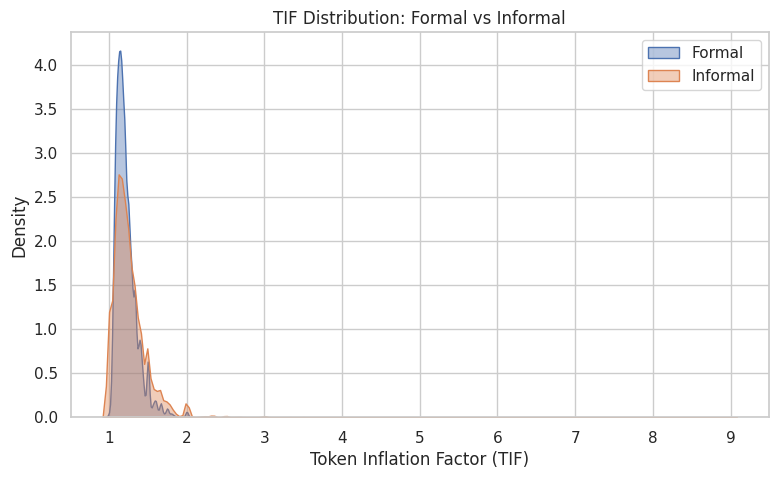

In [14]:
plt.figure(figsize=(9, 5))
sns.kdeplot(df["formal_TIF"], label="Formal", fill=True, alpha=0.4)
sns.kdeplot(df["informal_TIF"], label="Informal", fill=True, alpha=0.4)
plt.xlabel("Token Inflation Factor (TIF)")
plt.title("TIF Distribution: Formal vs Informal")
plt.legend()
plt.show()

Informal Persian typically has a *higher* TIF than formal Persian.
Since ParsBERT's subword vocabulary was learned mostly from formal, edited text, casual
spellings, slang, and contracted verb forms are less likely to exist as whole tokens in
its vocabulary, so the tokenizer has to split them into more subword pieces inflating
the token count relative to a simple whitespace split.

In [15]:
!pip install gensim -q
from gensim.models import Word2Vec

corpus= [s.split() for s in df["formalForm"]] + [s.split() for s in df["inFormalForm"]]

w2v_model= Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,
    workers=4,
    epochs=10,
    seed=SEED,
)

print("Vocabulary size:", len(w2v_model.wv))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 24.4 MB/s eta 0:00:00
Vocabulary size: 22712


In [16]:
target_words = []
for w, c in top20_formal:
    if w in w2v_model.wv and w not in target_words:
        target_words.append(w)
for w, c in top20_informal:
    if w in w2v_model.wv and w not in target_words:
        target_words.append(w)
target_words = target_words[:10]

for word in target_words:
    neighbors = w2v_model.wv.most_similar(word, topn=5)
    print(f"'{word}' nearest neighbors:")
    for n, score in neighbors:
        print(f"{n} (cos sim = {score:.3f})")
    print()

'را' nearest neighbors:
   او  (cos sim = 0.681)
   آن‌ها  (cos sim = 0.669)
   آن  (cos sim = 0.665)
   به‌زور  (cos sim = 0.652)
   نمی‌گذارد  (cos sim = 0.631)

'که' nearest neighbors:
   ک  (cos sim = 0.749)
   بدیش  (cos sim = 0.647)
   همچین  (cos sim = 0.644)
   بچس  (cos sim = 0.635)
   وقتیم  (cos sim = 0.634)

'و' nearest neighbors:
   آلود  (cos sim = 0.691)
   گرفته.  (cos sim = 0.684)
   م  (cos sim = 0.683)
   ایش  (cos sim = 0.678)
   رومو  (cos sim = 0.673)

'به' nearest neighbors:
   ب  (cos sim = 0.669)
   بهش  (cos sim = 0.599)
   نیروهای  (cos sim = 0.571)
   بهم  (cos sim = 0.567)
   مردم،  (cos sim = 0.558)

'از' nearest neighbors:
   ازش  (cos sim = 0.594)
   لذتای  (cos sim = 0.588)
   دوستامون  (cos sim = 0.581)
   خوبمو  (cos sim = 0.577)
   گزاری  (cos sim = 0.571)

'من' nearest neighbors:
   کشیده‌ام،  (cos sim = 0.676)
   نگرفتم،  (cos sim = 0.667)
   مهربانم  (cos sim = 0.666)
   خداحافظ،  (cos sim = 0.663)
   هیکلم  (cos sim = 0.660)

'هم' nearest neighbo

formal and informal versions of the same
concept show up close to each other in the neighbor lists, that suggests Word2Vec is partially converging formal/informal usages into a shared semantic neighborhood mostly because they tend to appear in similar surrounding contexts.

In [17]:
def sentence_vector_w2v(sentence, model):
    words= sentence.split()
    vectors= [model.wv[w] for w in words if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

def cosine_sim(a, b):
    denom= (np.linalg.norm(a) * np.linalg.norm(b))
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

In [18]:
n_eval = min(len(df), 2000)
eval_df = df.sample(n_eval, random_state=SEED).reset_index(drop=True)

formal_sentences= eval_df["formalForm"].tolist()
informal_sentences= eval_df["inFormalForm"].tolist()
rng= np.random.RandomState(SEED)
shuffled_idx= rng.permutation(len(informal_sentences))
shuffled_informal= [informal_sentences[i] for i in shuffled_idx]
random_informal= shuffled_informal[1:] + shuffled_informal[:1]

group_a_sims_w2v= []
group_b_sims_w2v= []

for f, i_true, i_rand in zip(formal_sentences, informal_sentences, random_informal):
    v_f = sentence_vector_w2v(f, w2v_model)
    v_true = sentence_vector_w2v(i_true, w2v_model)
    v_rand = sentence_vector_w2v(i_rand, w2v_model)
    group_a_sims_w2v.append(cosine_sim(v_f, v_true))
    group_b_sims_w2v.append(cosine_sim(v_f, v_rand))

print("Group A (true pairs) mean cosine similarity:", np.mean(group_a_sims_w2v))
print("Group B (random pairs) mean cosine similarity:", np.mean(group_b_sims_w2v))

Group A (true pairs) mean cosine similarity: 0.8048186515048146
Group B (random pairs) mean cosine similarity: 0.5786081278473139


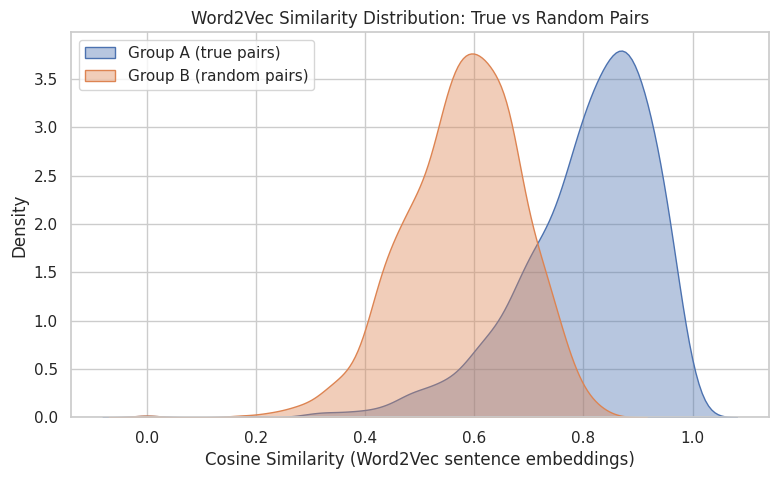

In [19]:
plt.figure(figsize=(9, 5))
sns.kdeplot(group_a_sims_w2v, label="Group A (true pairs)", fill=True, alpha=0.4)
sns.kdeplot(group_b_sims_w2v, label="Group B (random pairs)", fill=True, alpha=0.4)
plt.xlabel("Cosine Similarity (Word2Vec sentence embeddings)")
plt.title("Word2Vec Similarity Distribution: True vs Random Pairs")
plt.legend()
plt.show()

In [20]:
low_sim_examples= []
for f, i_true, sim in zip(formal_sentences, informal_sentences, group_a_sims_w2v):
    if sim < 0.4:
        low_sim_examples.append((f, i_true, sim))

print(f"Found {len(low_sim_examples)} true pairs with cosine similarity < 0.4\n")
for f, i_true, sim in low_sim_examples[:10]:
    print(f"sim={sim:.3f}")
    print("  Formal  :", f)
    print("  Informal:", i_true)
    print()

Found 17 true pairs with cosine similarity < 0.4

sim=0.000
  Formal  : ما را به سونوگرافی فرستادند.
  Informal: فرستادنمون سونو.

sim=0.304
  Formal  : هیچ‌وقت نمی‌دانستم این‌قدر بدذات هستی.
  Informal: هیچوقت نمدونستم انقد بدذاتی

sim=0.288
  Formal  : موادفروش‌ها آن‌ها را کشتند؟!
  Informal: مواد فروشا کشتنشون؟!

sim=0.000
  Formal  : شما را نمی‌بخشم.
  Informal: نمیبخشمتون

sim=0.368
  Formal  : دارد آن‌ها را برعکس می‌گذارد.
  Informal: داره اونا رو برعکس می ذاره.

sim=0.372
  Formal  : او می‌گوید من شیطان هستم، این‌طور است؟
  Informal: اون میگه من شیطانم، اینطوریه؟

sim=0.326
  Formal  : همین جوری هم سه‌هیچ جلو هستی.
  Informal: همینجوریشم سه هیچ جلویی.

sim=0.322
  Formal  : تفاوتشان در منافعشان مستتر است.
  Informal: تفاوتشون تو منافعشون مستتره.

sim=0.393
  Formal  : استاد چرایش را نمی‌دانم!
  Informal: چراشو نمیدونم استاد!

sim=0.202
  Formal  : آنجا منتظرت هستم.
  Informal: اونجا منتظرتم.



Pairs with a low Word2Vec similarity score are usually ones where
the informal sentence replaces several formal words with completely different informal
spellings/slang that share little surface overlap, or where many words in the sentence
are short/rare and got dropped or barely trained during Word2Vec training (`min_count`
filtering). Since Word2Vec sentence vectors are just an unweighted average of word
vectors, sentences with very different surface vocabulary can end up far apart in vector space.

In [21]:
import torch
from transformers import AutoModel

device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model= AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_model.eval()

print("Using device:", device)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  654MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: HooshvareLab/bert-fa-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  654MB            

model.safetensors: downloading bytes:           |  0.00B            

Using device: cuda


In [22]:
@torch.no_grad()
def sentence_vector_bert(sentence, method="mean"):
    inputs= tokenizer(sentence, return_tensors="pt", truncation=True, max_length=64)
    inputs= {k: v.to(device) for k, v in inputs.items()}
    outputs= bert_model(**inputs)
    last_hidden= outputs.last_hidden_state[0]

    if method == "cls":
        vector= last_hidden[0]
    else:
        vector= last_hidden.mean(dim=0)

    return vector.cpu().numpy()
v = sentence_vector_bert(df.iloc[0]["formalForm"])
print("ParsBERT sentence vector shape:", v.shape)

ParsBERT sentence vector shape: (768,)


In [26]:
@torch.no_grad()
def sentence_vectors_bert_batch(sentences, method="mean", batch_size=32):
    vectors= []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                          max_length=64, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = bert_model(**inputs)
        last_hidden = outputs.last_hidden_state

        if method == "cls":
            batch_vectors = last_hidden[:, 0, :]
        else:
            mask= inputs["attention_mask"].unsqueeze(-1)
            sum_vectors= (last_hidden * mask).sum(dim=1)
            lengths= mask.sum(dim=1)
            batch_vectors= sum_vectors/lengths

        vectors.extend(batch_vectors.cpu().numpy())
    return vectors

v_formals = sentence_vectors_bert_batch(formal_sentences, batch_size=32)
v_true_informals = sentence_vectors_bert_batch(informal_sentences, batch_size=32)
v_random_informals = sentence_vectors_bert_batch(random_informal, batch_size=32)
group_a_sims_bert = [cosine_sim(f, t) for f, t in zip(v_formals, v_true_informals)]
group_b_sims_bert = [cosine_sim(f, r) for f, r in zip(v_formals, v_random_informals)]

print("Group A (true pairs)   mean cosine similarity:", np.mean(group_a_sims_bert))
print("Group B (random pairs) mean cosine similarity:", np.mean(group_b_sims_bert))

Group A (true pairs)   mean cosine similarity: 0.8080153540372849
Group B (random pairs) mean cosine similarity: 0.5463556579947472


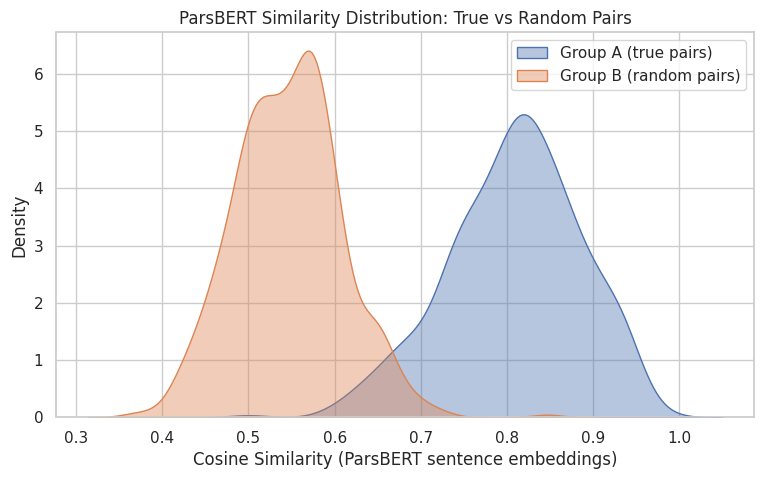

In [27]:
plt.figure(figsize=(9, 5))
sns.kdeplot(group_a_sims_bert, label="Group A (true pairs)", fill=True, alpha=0.4)
sns.kdeplot(group_b_sims_bert, label="Group B (random pairs)", fill=True, alpha=0.4)
plt.xlabel("Cosine Similarity (ParsBERT sentence embeddings)")
plt.title("ParsBERT Similarity Distribution: True vs Random Pairs")
plt.legend()
plt.show()

ParsBERT usually shows a wider separation between true and random pairs,
because its contextual, attention-based representations capture meaning beyond just
shared surface words. it can recognize that two sentences describe the same thing even
when the informal version uses completely different (contracted/slang) vocabulary, which
a simple average-of-word-vectors approach cannot do as well.

In [28]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

n_viz= min(len(eval_df), 500)
viz_df= eval_df.iloc[:n_viz].reset_index(drop=True)

w2v_vectors= []
bert_vectors= []
labels= []

for _, row in viz_df.iterrows():
    w2v_vectors.append(sentence_vector_w2v(row["formalForm"], w2v_model))
    w2v_vectors.append(sentence_vector_w2v(row["inFormalForm"], w2v_model))
    bert_vectors.append(sentence_vector_bert(row["formalForm"], method="mean"))
    bert_vectors.append(sentence_vector_bert(row["inFormalForm"], method="mean"))
    labels.append("formal")
    labels.append("informal")

w2v_vectors = np.array(w2v_vectors)
bert_vectors = np.array(bert_vectors)
labels = np.array(labels)

print(w2v_vectors.shape, bert_vectors.shape)

(1000, 100) (1000, 768)


In [30]:
def reduce_2d(vectors, method="pca"):
    if method == "pca":
        reducer = PCA(n_components=2, random_state=SEED)
    else:
        reducer = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30)
    return reducer.fit_transform(vectors)

w2v_pca= reduce_2d(w2v_vectors, "pca")
w2v_tsne= reduce_2d(w2v_vectors, "tsne")
bert_pca= reduce_2d(bert_vectors, "pca")
bert_tsne= reduce_2d(bert_vectors, "tsne")

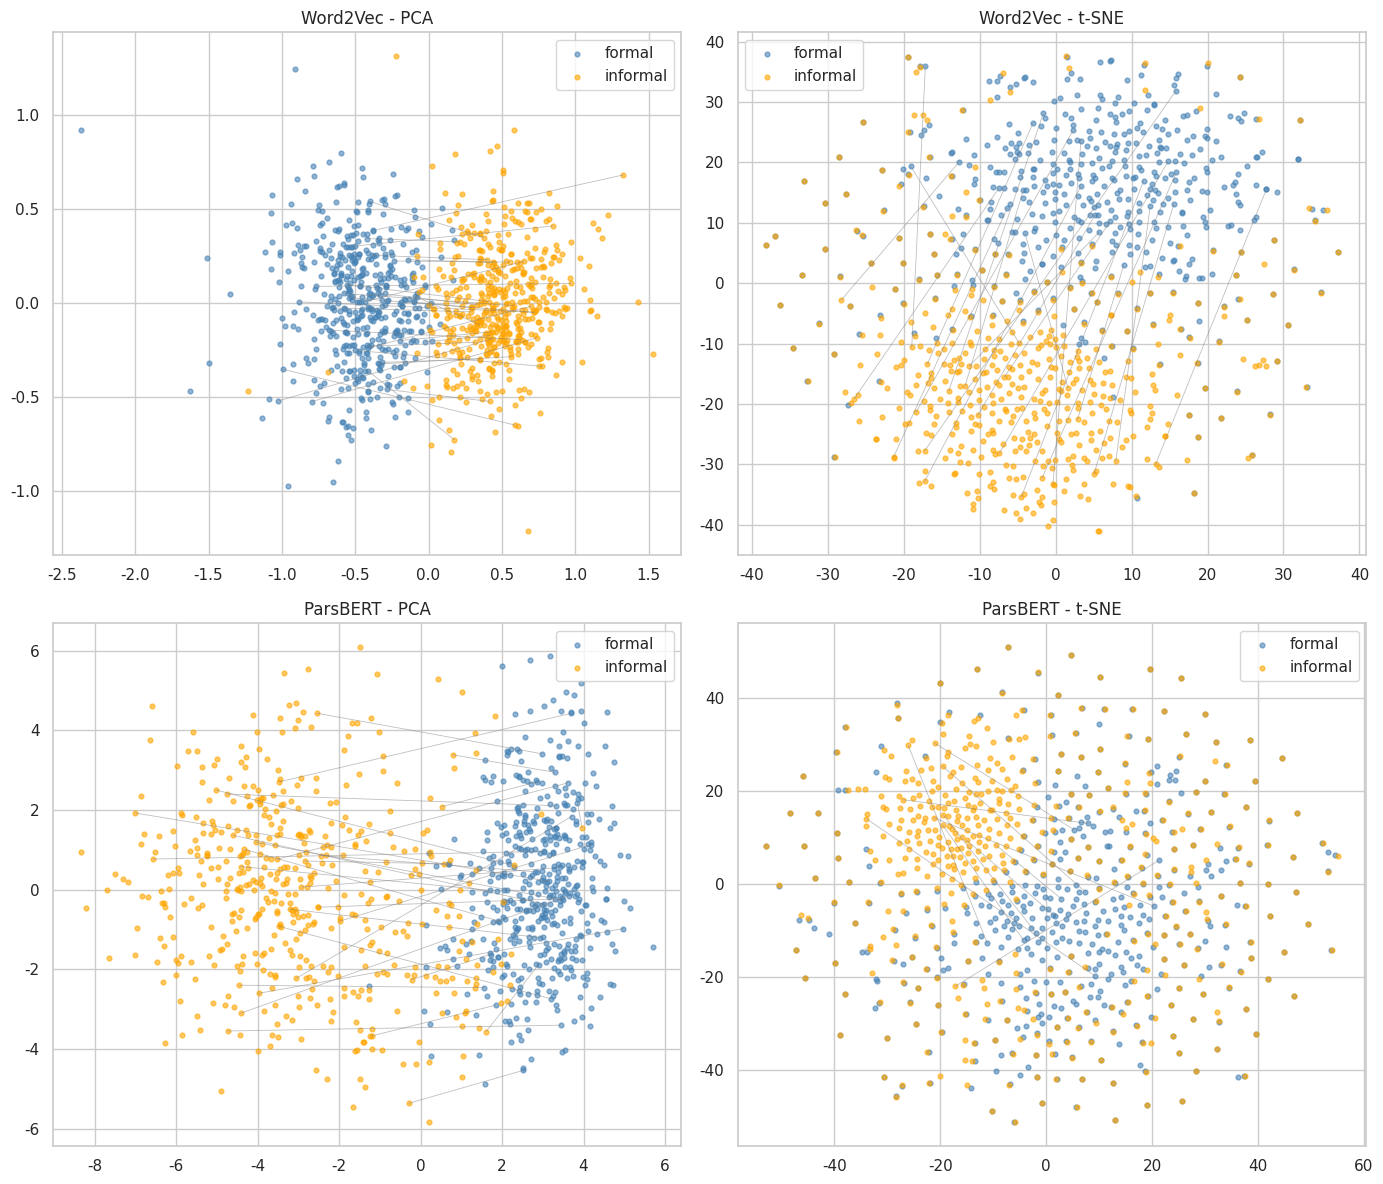

In [31]:
def plot_embedding_space(points, labels, n_pairs_to_connect, title, ax):
    colors = {"formal": "steelblue", "informal": "orange"}
    for label in ["formal", "informal"]:
        mask = labels == label
        ax.scatter(points[mask, 0], points[mask, 1], s=12, alpha=0.6,
                   c=colors[label], label=label)
    n_points = len(points)
    n_sentences = n_points // 2
    chosen = np.random.RandomState(SEED).choice(n_sentences, size=min(n_pairs_to_connect, n_sentences), replace=False)
    for idx in chosen:
        f_point= points[2 * idx]
        i_point= points[2 * idx + 1]
        ax.plot([f_point[0], i_point[0]], [f_point[1], i_point[1]],
                c="gray", linewidth=0.6, alpha=0.5)
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plot_embedding_space(w2v_pca, labels, 30, "Word2Vec - PCA", axes[0, 0])
plot_embedding_space(w2v_tsne, labels, 30, "Word2Vec - t-SNE", axes[0, 1])
plot_embedding_space(bert_pca, labels, 30, "ParsBERT - PCA", axes[1, 0])
plot_embedding_space(bert_tsne, labels, 30, "ParsBERT - t-SNE", axes[1, 1])
plt.tight_layout()
plt.show()

**Discussion:** In the Word2Vec plots, the lines connecting formal/informal pairs
tend to be longer and the two colors may form more separate clusters, since Word2Vec
sentence vectors are sensitive to the exact surface words used. In the ParsBERT plots,
equivalent pairs usually sit closer together, and the connecting lines are shorter on
average. even though the two style clusters may still be loosely visible .because
ParsBERT's contextual representations pick up on meaning rather than exact wording. This
suggests ParsBERT better aligns semantically equivalent formal/informal expressions than
Word2Vec, which relies on lexical overlap. Update this note with what you actually
observe in your plots.

In [32]:
shuffled_df= df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n_total= len(shuffled_df)
n_train= int(0.8 * n_total)
n_val= int(0.1 * n_total)

train_rows= shuffled_df.iloc[:n_train].reset_index(drop=True)
val_rows= shuffled_df.iloc[n_train:n_train + n_val].reset_index(drop=True)
test_rows= shuffled_df.iloc[n_train + n_val:].reset_index(drop=True)

print("train rows:", len(train_rows), "val rows:", len(val_rows), "test rows:", len(test_rows))

train rows: 32014 val rows: 4001 test rows: 4003


In [34]:
def make_pair_dataset(rows, seed):
    formals= rows["formalForm"].tolist()
    informals= rows["inFormalForm"].tolist()

    rng= np.random.RandomState(seed)
    shuffled_idx= rng.permutation(len(informals))
    shuffled_informals= [informals[i] for i in shuffled_idx]
    negative_informals= shuffled_informals[1:] + shuffled_informals[:1]

    pos= pd.DataFrame({
        "formalForm": formals,
        "inFormalForm": informals,
        "label": 1,
    })
    neg= pd.DataFrame({
        "formalForm": formals,
        "inFormalForm": negative_informals,
        "label": 0,
    })

    combined= pd.concat([pos, neg], ignore_index=True)
    combined= combined.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return combined

train_pairs= make_pair_dataset(train_rows, seed=SEED)
val_pairs= make_pair_dataset(val_rows, seed=SEED+1)
test_pairs= make_pair_dataset(test_rows, seed=SEED+2)

print("train pairs:", len(train_pairs), "label balance:\n", train_pairs["label"].value_counts())
print("val pairs  :", len(val_pairs))
print("test pairs :", len(test_pairs))
train_pairs.head()

train pairs: 64028 label balance:
 label
1    32014
0    32014
Name: count, dtype: int64
val pairs  : 8002
test pairs : 8006


,formalForm,inFormalForm,label
0,وقتی نفس می‌کشی ریه‌هایت می‌سوزد.,وقتی نفس می کشی ریه هات می سوزه,1
1,ان‌شاءالله همگی‌تان به‌زودی باردار شوید.,ان شااله همگیتون به زودی باردار شین.,1
2,تو خوب هستی؟ سلامت هستی؟,یه عده دار و دسته و عواملم داشتن که من همشونو خوب می‌شناسم.,0
3,جدیداً از شنبه یکشنبه خوشم نمی‌آید؛ ولی از دوشنبه تا جمعه را دوست دارم.,خدایا فاصلت تا من خودت گفتی که کوتاهه.,0
4,تازه چشم این هاپو باز شده است.,مطمئنم سر جاشونن.,0


In [37]:
sample_encoding= tokenizer(
    train_pairs.iloc[0]["formalForm"],
    train_pairs.iloc[0]["inFormalForm"],
    padding="max_length",
    truncation=True,
    max_length=64,
    return_tensors="pt",
)

print("formal:", train_pairs.iloc[0]["formalForm"])
print("informal:", train_pairs.iloc[0]["inFormalForm"])
print("label:", train_pairs.iloc[0]["label"])
print("input_ids:\n", sample_encoding["input_ids"])
print("attention_mask:\n", sample_encoding["attention_mask"])
print("token_type_ids:\n", sample_encoding["token_type_ids"])
print("Decoded tokens:")
print(tokenizer.convert_ids_to_tokens(sample_encoding["input_ids"][0]))

formal: وقتی نفس می‌کشی ریه‌هایت می‌سوزد.
informal: وقتی نفس می کشی ریه هات می سوزه
label: 1
input_ids:
 tensor([[    2,  3711,  6346, 88270, 44322,  2009, 27154,  1012,     4,  3711,
          6346,  2793, 10508, 10806, 13581,  2793,  6705,  2008,     4,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]])
attention_mask:
 tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
token_type_ids:
 tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

**What each array means:**

- **input_ids**: the numeric IDs of the tokens produced by the tokenizer. The sequence
  starts with the CLS token (used later as a pooled representation of the whole
  pair), the formal sentence tokens, then a SEP token, then the informal sentence
  tokens, then a final SEP token. Anything after the two sentences up to
  max_length is padding (PAD, id 0).
- **attention_mask**: a 0/1 mask the same length as input_ids 1 for real tokens
  (including CLS/SEP) and 0 for PAD positions, so the model's attention
  layers ignore padding when sequences in a batch have different lengths.
- **token_type_ids / segment ids**: marks which of the two sentences each token
  belongs to 0 for tokens belonging to the first sentence (formal, including
  CLS and the first SEP) and 1 for tokens belonging to the second sentence
  (informal, including its trailing SEP). This lets the model distinguish
  "sequence A" from "sequence B" even though they're packed into a single input.

In [39]:
from torch.utils.data import Dataset, DataLoader
MAX_LEN= 64

class PairDataset(Dataset):
    def __init__(self, pairs_df, tokenizer, max_len=MAX_LEN):
        self.formal = pairs_df["formalForm"].tolist()
        self.informal = pairs_df["inFormalForm"].tolist()
        self.labels = pairs_df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.formal[idx],
            self.informal[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        item= {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset= PairDataset(train_pairs, tokenizer)
val_dataset= PairDataset(val_pairs, tokenizer)
test_dataset= PairDataset(test_pairs, tokenizer)

BATCH_SIZE= 16
train_loader= DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader= DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader= DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print("train batches:", len(train_loader), "val batches:", len(val_loader))

train batches: 4002 val batches: 501


In [40]:
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

classifier= AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
classifier.to(device)

LEARNING_RATE= 2e-5
NUM_EPOCHS= 3

optimizer= AdamW(classifier.parameters(), lr=LEARNING_RATE)

total_steps= len(train_loader)*NUM_EPOCHS
scheduler= get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1*total_steps),
    num_training_steps=total_steps,
)

print("Total training steps:", total_steps)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-fa-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	thos

Total training steps: 12006


In [41]:
def run_validation(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            total_loss += outputs.loss.item()
    return total_loss / len(loader)

In [42]:
train_losses= []
val_losses= []
train_loss_steps= []
val_loss_epochs= []
LOG_EVERY= 50
global_step= 0

classifier.train()
for epoch in range(NUM_EPOCHS):
    running_loss= 0.0
    for batch in train_loader:
        batch= {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs= classifier(**batch)
        loss= outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        global_step += 1

        if global_step % LOG_EVERY == 0:
            avg_loss = running_loss / LOG_EVERY
            train_losses.append(avg_loss)
            train_loss_steps.append(global_step)
            running_loss = 0.0
            print(f"epoch {epoch+1} step {global_step}: train loss = {avg_loss:.4f}")

    val_loss = run_validation(classifier, val_loader)
    val_losses.append(val_loss)
    val_loss_epochs.append(global_step)
    print(f"epoch {epoch+1} done: validation loss = {val_loss:.4f}")
    classifier.train()

epoch 1 step 50: train loss = 0.8456
epoch 1 step 100: train loss = 0.6899
epoch 1 step 150: train loss = 0.4641
epoch 1 step 200: train loss = 0.1933
epoch 1 step 250: train loss = 0.0686
epoch 1 step 300: train loss = 0.0492
epoch 1 step 350: train loss = 0.0549
epoch 1 step 400: train loss = 0.0423
epoch 1 step 450: train loss = 0.0197
epoch 1 step 500: train loss = 0.0335
epoch 1 step 550: train loss = 0.0146
epoch 1 step 600: train loss = 0.0296
epoch 1 step 650: train loss = 0.0274
epoch 1 step 700: train loss = 0.0197
epoch 1 step 750: train loss = 0.0154
epoch 1 step 800: train loss = 0.0032
epoch 1 step 850: train loss = 0.0316
epoch 1 step 900: train loss = 0.0133
epoch 1 step 950: train loss = 0.0246
epoch 1 step 1000: train loss = 0.0166
epoch 1 step 1050: train loss = 0.0032
epoch 1 step 1100: train loss = 0.0301
epoch 1 step 1150: train loss = 0.0209
epoch 1 step 1200: train loss = 0.0270
epoch 1 step 1250: train loss = 0.0190
epoch 1 step 1300: train loss = 0.0110
epoch 

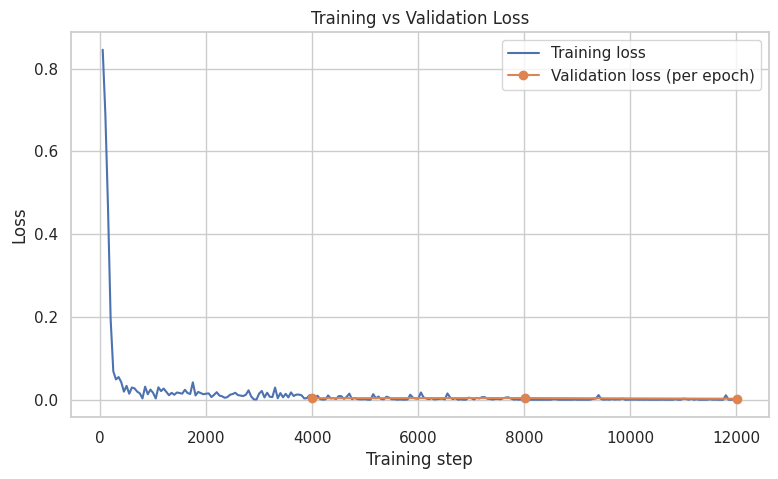

In [43]:
plt.figure(figsize=(9, 5))
plt.plot(train_loss_steps, train_losses, label="Training loss")
plt.plot(val_loss_epochs, val_losses, marker="o", label="Validation loss (per epoch)")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [44]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

@torch.no_grad()
def evaluate_on_loader(model, loader):
    model.eval()
    all_labels= []
    all_preds= []
    all_probs= []
    for batch in loader:
        labels = batch["labels"].numpy()
        model_inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        outputs = model(**model_inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        all_labels.extend(labels.tolist())
        all_preds.extend(preds.tolist())
        all_probs.extend(probs[:, 1].tolist())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

test_labels, test_preds, test_probs= evaluate_on_loader(classifier, test_loader)
accuracy = accuracy_score(test_labels, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels, test_preds, average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Accuracy : 0.9996
Precision: 0.9996
Recall   : 0.9996
F1-score : 0.9996


In [45]:
results_df= test_pairs.copy()
results_df["true_label"]= test_labels
results_df["pred_label"]= test_preds
results_df["pred_prob_equivalent"]= test_probs

true_positives= results_df[(results_df["true_label"] == 1) & (results_df["pred_label"] == 1)]
true_negatives= results_df[(results_df["true_label"] == 0) & (results_df["pred_label"] == 0)]
false_positives= results_df[(results_df["true_label"] == 0) & (results_df["pred_label"] == 1)]
false_negatives= results_df[(results_df["true_label"] == 1) & (results_df["pred_label"] == 0)]

print("True Positives :", len(true_positives))
print("True Negatives :", len(true_negatives))
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

True Positives : 4002
True Negatives : 4001
False Positives: 2
False Negatives: 1


In [50]:
print("Sample True Positives (equivalent pairs correctly matched)")
for _, row in true_positives.head(5).iterrows():
    print(f"prob={row['pred_prob_equivalent']:.3f}  formal: {row['formalForm']}")
    print(f"informal: {row['inFormalForm']}")

print("Sample True Negatives (random pairs correctly rejected)")
for _, row in true_negatives.head(5).iterrows():
    print(f"prob={row['pred_prob_equivalent']:.3f}  formal: {row['formalForm']}")
    print(f"informal: {row['inFormalForm']}")

Sample True Positives (equivalent pairs correctly matched)
prob=1.000  formal: ما دخترها باید دم‌به‌ساعت برای او کشیک می‌دادیم، تا این دو تا با هم ملاقات کنند.
informal: ما دخترا باید دم به ساعت براش کشیک میدادیم تا این دوتا باهم ملاقات کنن
prob=1.000  formal: حاج‌آقا به عروس‌خانم می‌گوید وکیل هستم؟ عروس می‌گوید: پس نه پس در این بی‌شوهری می‌روم گل می‌چینم!
informal: حاج آقا به عروس خانوم میگه وکیلم؟ عروس میگه پ نه پ تو این بی شوهری میرم گل میچینم
prob=1.000  formal: دیگر هیچ‌چیز از خدا نمی‌خوام؛ چون اگر عاشق خدا باشند، عاشق حکومت الهی و توحیدی در سرتاسر جهان هم هستند.
informal: دیگه هیچی از خدا نمی خوام چون اگر عاشق خدا باشن عاشق حکومت الهی و توحیدی سرتاسر جهانم هستن.
prob=1.000  formal: این بچه سردی‌اش کرده است.
informal: ای بچه سردیش کرده.
prob=1.000  formal: مامانم به من اشاره کرد و من هم رفتم و کنار او نشستم.
informal: مامانم بهم اشاره کرد و منم رفتم و کنارش نشستم.
Sample True Negatives (random pairs correctly rejected)
prob=0.000  formal: نیمۀ اول زندگی‌اش برای پیدا کردن زن مورد ع

**Success analysis:** Look at the True Positive / True Negative examples above.
Correct matches (TP) are usually pairs that still share some recognizable root words or
common conversational patterns that the fine-tuned model learned to associate with
equivalence. Correct rejections (TN) are usually pairs whose topics/subjects are clearly
unrelated, giving the model an easy signal that they don't describe the same thing.

In [51]:
print("False Positives (unrelated pairs predicted as equivalent)")
for _, row in false_positives.head(5).iterrows():
    print(f"prob={row['pred_prob_equivalent']:.3f}  formal: {row['formalForm']}")
    print(f"informal: {row['inFormalForm']}")
    print()

print("False Negatives (true pairs predicted as not equivalent)")
for _, row in false_negatives.head(5).iterrows():
    print(f"prob={row['pred_prob_equivalent']:.3f}  formal: {row['formalForm']}")
    print(f"informal: {row['inFormalForm']}")
    print()

False Positives (unrelated pairs predicted as equivalent)
prob=0.988  formal: صبحتان به‌خیر.
informal: صبح زیبای بهاریتون بخیر

prob=0.930  formal: بعضی از سالادها هم هستند که می‌توانند به عنوان وعدۀ غذایی اصلی خورده بشوند.
informal: حتما امینم گرسنه اس خودمونم که صبحانه نخوردیم.

False Negatives (true pairs predicted as not equivalent)
prob=0.338  formal: صدایم خیلی تودماغی است.
informal: صدام خیلی تو دماغیه.



**Error analysis:** False positives often happen when the randomly paired informal
sentence happens to share topical vocabulary with the formal sentence by coincidence.
False negatives often happen when the informal sentence uses very heavy contraction,
slang, or dropped words, making it look surface-wise very different from its true
formal match even though the underlying meaning is the same. the model may be relying
too much on shared vocabulary cues rather than deeper meaning in these cases.

In [52]:
@torch.no_grad()
def predict_equivalence(formal_sentence, informal_sentence, model=classifier, tok=tokenizer, threshold=0.5):
    model.eval()
    encoding = tok(
        formal_sentence,
        informal_sentence,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt",
    )
    encoding= {k: v.to(device) for k, v in encoding.items()}
    outputs= model(**encoding)
    prob_equivalent= torch.softmax(outputs.logits, dim=1)[0, 1].item()
    predicted_label= 1 if prob_equivalent >= threshold else 0

    return {
        "formal": formal_sentence,
        "informal": informal_sentence,
        "predicted_label": predicted_label,
        "prediction": "equivalent" if predicted_label == 1 else "not equivalent",
        "confidence": prob_equivalent,
    }

In [49]:
custom_examples= [
    ("امروز هوا بسیار خوب است.", "امروز هوا خیلی خوبه."),
    ("من قصد دارم فردا به دانشگاه بروم.", "من فردا میرم دانشگاه."),
    ("لطفا کتاب را روی میز بگذارید.", "امشب فیلم خوبی پخش میشه."),
]

for formal_sentence, informal_sentence in custom_examples:
    result= predict_equivalence(formal_sentence, informal_sentence)
    print(result)
    print()

{'formal': 'امروز هوا بسیار خوب است.', 'informal': 'امروز هوا خیلی خوبه.', 'predicted_label': 1, 'prediction': 'equivalent', 'confidence': 0.9999936819076538}

{'formal': 'من قصد دارم فردا به دانشگاه بروم.', 'informal': 'من فردا میرم دانشگاه.', 'predicted_label': 1, 'prediction': 'equivalent', 'confidence': 0.9999856948852539}

{'formal': 'لطفا کتاب را روی میز بگذارید.', 'informal': 'امشب فیلم خوبی پخش میشه.', 'predicted_label': 0, 'prediction': 'not equivalent', 'confidence': 5.239052370598074e-06}

